In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [10]:
df = pd.read_csv("marketing_campaign.csv", sep=";")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [12]:
df = df.drop_duplicates()

In [13]:
df = df.dropna()

In [15]:
df['Age'] = 2024 - df['Year_Birth']

In [16]:
df['Response'].value_counts()

,count
Response,
0,1883
1,333


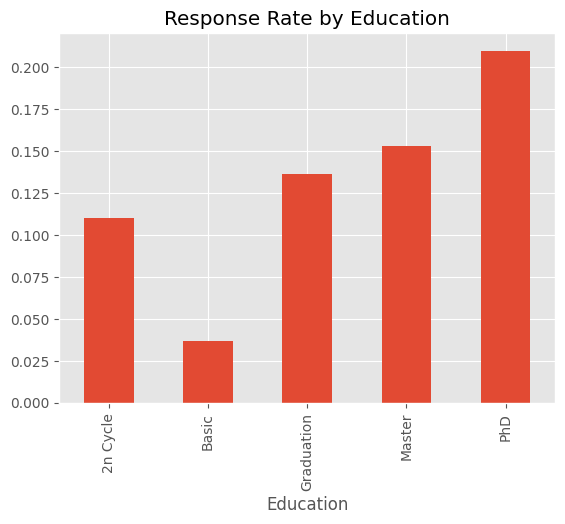

In [17]:
df.groupby('Education')['Response'].mean().plot(kind='bar')
plt.title("Response Rate by Education")
plt.show()

/tmp/ipykernel_1778/2177727886.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Income'], 4))['Response'].mean().plot(kind='bar')


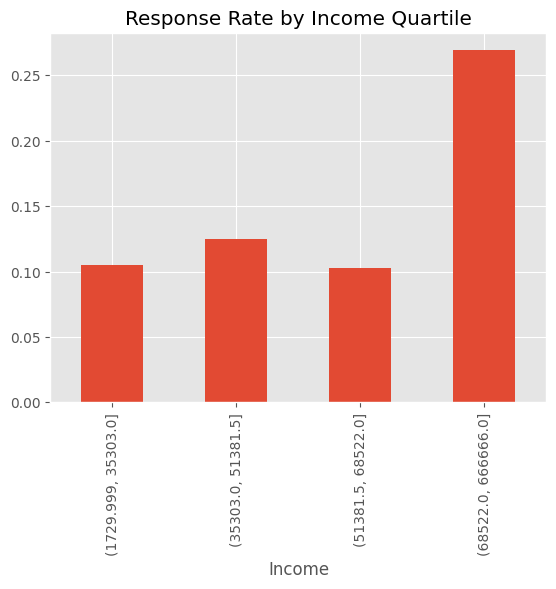

In [18]:
df.groupby(pd.qcut(df['Income'], 4))['Response'].mean().plot(kind='bar')
plt.title("Response Rate by Income Quartile")
plt.show()

In [26]:
df['Marital_Status'] = df['Marital_Status'].replace(
    ['Absurd','YOLO'], 'Single'
)

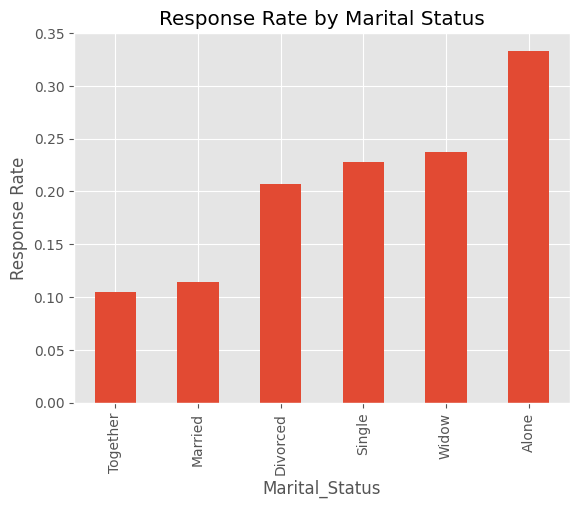

In [27]:
df.groupby('Marital_Status')['Response'].mean().sort_values().plot(kind='bar')
plt.title("Response Rate by Marital Status")
plt.ylabel("Response Rate")
plt.show()

In [20]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[18,30,40,50,60,100],
                         labels=['18-30','31-40','41-50','51-60','60+'])

/tmp/ipykernel_1778/3855686747.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Response'].mean().plot(kind='bar')


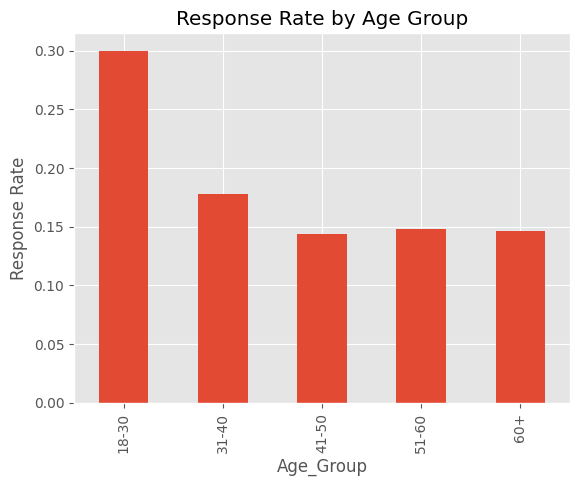

In [21]:
df.groupby('Age_Group')['Response'].mean().plot(kind='bar')
plt.title("Response Rate by Age Group")
plt.ylabel("Response Rate")
plt.show()

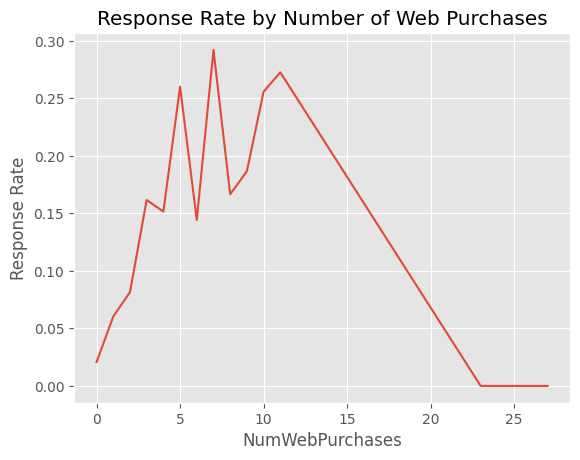

In [22]:
df.groupby('NumWebPurchases')['Response'].mean().plot(kind='line')
plt.title("Response Rate by Number of Web Purchases")
plt.ylabel("Response Rate")
plt.show()

In [24]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                           'MntFishProducts','MntSweetProducts',
                           'MntGoldProds']].sum(axis=1)

/tmp/ipykernel_1778/89924845.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Total_Spending'],4))['Response'].mean().plot(kind='bar')


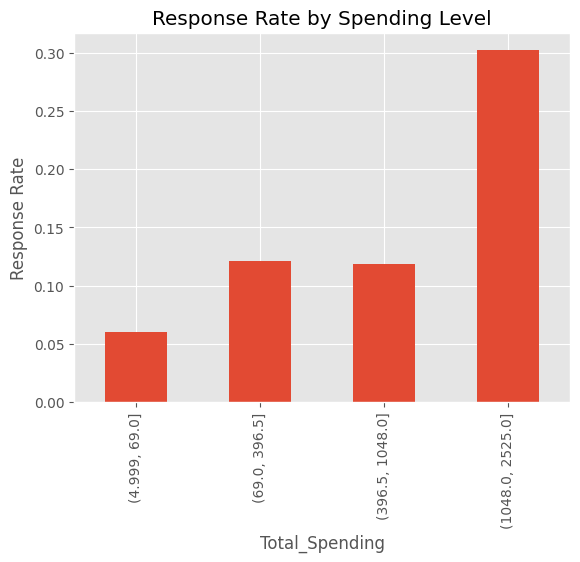

In [25]:
df.groupby(pd.qcut(df['Total_Spending'],4))['Response'].mean().plot(kind='bar')
plt.title("Response Rate by Spending Level")
plt.ylabel("Response Rate")
plt.show()